In [1]:
import pandas as pd 
from torchvision.datasets import ImageFolder
from collections import defaultdict
from tqdm import trange
from scipy.stats import norm
import numpy as np

df = pd.read_csv('../dataset.csv', index_col='Unnamed: 0')

In [2]:
def kl_div(mu1: float, sigma1: float, mu2: float, sigma2: float) -> float:
    sigma1 = np.maximum(sigma1, 1e-9)
    sigma2 = np.maximum(sigma2, 1e-9)
    return np.log(sigma2 / sigma1) + (sigma1**2 + (mu1 - mu2)**2) / (2 * sigma2**2) - 0.5

labels = df['label'].values
sizes = df['size'].values

label0_idx = labels == 0
label1_idx = labels == 1
malicious = df[label1_idx]
benign = df[label0_idx]

mean_m, std_m = norm.fit(malicious['size'])
mean_b, std_b = norm.fit(benign['size'])

baseline = kl_div(mean_m, std_m, mean_b, std_b)
print(f"Benign:\t\tN({mean_b:.2f}, {std_b:.2f})")
print(f"Malicious:\tN({mean_m:.2f}, {std_m:.2f})")
print(f"D_kl:\t\t{baseline:.2f}")

Benign:		N(5590070.22, 40660341.34)
Malicious:	N(359094.90, 528201.21)
D_kl:		3.85


In [3]:
POPULATION_SIZE = 1000
GENERATIONS = 1000
MUTATION_RATE = 0.0005

OFFSET = 0
FACTOR = -1

In [4]:
def init_population(best = None):
    if best is None:
        return np.full((POPULATION_SIZE, len(df)), True)
    else:
        return np.repeat(best[np.newaxis, :], POPULATION_SIZE, axis=0)


def mutate_mask(mask, rate = MUTATION_RATE):
    a = np.random.rand(len(mask)) < rate 
    return np.bitwise_xor(mask, a)

def fitness_fn(mask, return_dict=False):
    masked_labels = labels[mask]
    masked_sizes = sizes[mask]

    mal_size = masked_sizes[masked_labels == 1]
    ben_size = masked_sizes[masked_labels == 0]

    if len(mal_size) < 2 or len(ben_size) < 2:
        D_kl = np.inf
    else:
        mu_m, sigma_m = norm.fit(mal_size)
        mu_b, sigma_b = norm.fit(ben_size)
        D_kl = kl_div(mu_m, sigma_m, mu_b, sigma_b)

    n_ben = np.count_nonzero(mask[label0_idx])
    n_mal = np.count_nonzero(mask[label1_idx])

    ratio = 1.0 if n_mal == 0 else np.clip(1.0 - (n_ben / n_mal), 0.0, 1.0)


    w_d = -(np.exp(OFFSET + FACTOR * D_kl) / (1 + np.exp(OFFSET + FACTOR * D_kl))) + 1
    w_r = 1 - w_d

    fitness = {
        'overall': w_d * D_kl + w_r * ratio,
        'D_kl': D_kl,
        'ratio': ratio,
        'W_d': w_d,
        'W_r': w_r,
    }

    return fitness if return_dict else fitness['overall']

def simulate_generation(best = None):
    population = init_population(best)
    prior = np.array([fitness_fn(p) for p in population])
    offspring = np.apply_along_axis(mutate_mask, axis=1, arr=population)
    post = np.array([fitness_fn(o) for o in offspring])

    better = post < prior
    next_generation = np.where(better[:, np.newaxis], offspring, population)
    
    fitness = np.where(better, post, prior)

    best_idx = np.argmin(fitness)
    best = next_generation[best_idx]
    return best, fitness_fn(best, return_dict=True)

def has_stagnated(f, s):
    if len(f) < s: 
        return False 
    
    return np.all(np.diff(f[-s:]) >= 0)

def simulate():
    history = defaultdict(list)
    loop = trange(GENERATIONS)
    best = None

    for i in loop:
        best, fitness = simulate_generation(best)
        [history[f].append(fitness[f]) for f in fitness]
        loop.set_postfix_str(f"F: {fitness['overall']:.2f}, D_kl: {fitness['D_kl']:.2f}, R: {fitness['ratio']:.2f}")

        if has_stagnated(history['overall'], 10):
            loop.write("Early stopping criteria matched")
            loop.close()
            break
    return best, history

best, history = simulate()

 63%|██████▎   | 632/1000 [02:41<01:34,  3.91it/s, F: 0.00, D_kl: 0.00, R: 0.00]

Early stopping criteria matched


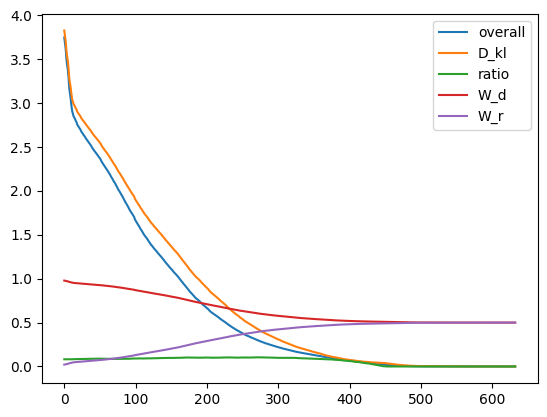

In [5]:
import matplotlib.pyplot as plt 

for metric in history: 
    plt.plot(history[metric], label=metric)
plt.legend()

In [6]:
df = df[best]

{'whiskers': [<matplotlib.lines.Line2D at 0x174547490>,
 'caps': [<matplotlib.lines.Line2D at 0x1745b4c50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1745a6a10>,
 'medians': [<matplotlib.lines.Line2D at 0x1745b6450>,
 'fliers': [<matplotlib.lines.Line2D at 0x1745b6e90>,
 'means': []}

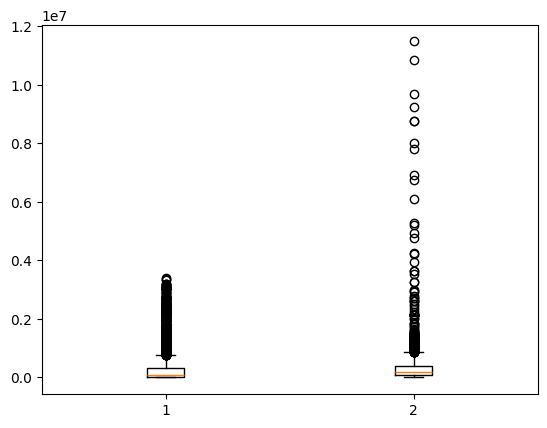

In [7]:
plt.boxplot([df[df['label'] == 0]['size'], df[df['label'] == 1]['size']])

In [8]:
print("Dataset size statistics (kB)")
(df['size'] * 1e-4).describe()

Dataset size statistics (kB)


count    7459.000000
mean       33.426131
std        60.920812
min         0.007600
25%         4.554800
50%        14.028800
75%        35.356000
max      1148.552300
Name: size, dtype: float64

In [9]:
df['label'].value_counts()

label
0    3834
1    3625
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import torchvision.transforms.v2 as v2
import torch

def is_selected(path):
    return path.split('/')[-1] in list(map(lambda p: p.split('/')[-1], df['image'].tolist()))
    # return True

transform = v2.Compose([
    v2.ToImage(), 
    v2.ToDtype(torch.float32)
])
dataset = ImageFolder('../data', is_valid_file=is_selected, transform=transform)
idxs = list(range(len(dataset)))
train_idxs, test_idxs = train_test_split(idxs, stratify=dataset.targets)
train = Subset(dataset, train_idxs)
test = Subset(dataset, test_idxs)
train_loader = DataLoader(train, batch_size=32)
test_loader = DataLoader(test, batch_size=32)

In [14]:
import torchvision
import torch.nn as nn 


model = torchvision.models.efficientnet_b0()
model.set_submodule('classifier.1', nn.Linear(in_features=1280, out_features=2))
model = model.to('mps')

In [ ]:
from sklearn.metrics import classification_report
from tqdm import tqdm 
import torch 
import torch.nn.functional as F

def train(loader, model, optim, criterion, epoch=0):
    train_loss = []
    train_loop = tqdm(loader, leave=False)

    train_loop.set_description_str(f"Train {epoch + 1:02}/{EPOCHS}")

    for img, label in train_loop:
        img = img.to('mps')
        label = F.one_hot(label, 2).to(torch.float32).to('mps')
        
        optim.zero_grad() 
        output = model(img)
        loss = criterion(output, label)
        train_loss.append(loss)
        loss.backward() 
        optim.step()

    return sum(train_loss) / len(train_loss)

def test(loader, model, criterion, epoch=0):
    model.eval()

    loop = tqdm(loader, leave=False)
    predicted = []
    actual = []
    test_loss = []

    loop.set_description_str(f"Test epoch {epoch+1:02}/{EPOCHS}")

    for img, label in loop: 
        img = img.to('mps')    
        label = F.one_hot(label, 2).to(torch.float32).to('mps')

        with torch.no_grad():
            output = model(img)

        loss = criterion(output, label)
        test_loss.append(loss)

        y_hat = output.argmax(dim=-1)
        y = label.argmax(dim=-1)

        predicted.append(y_hat)
        actual.append(y)

    predicted = torch.hstack(predicted).cpu()
    actual = torch.hstack(actual).cpu()

    model.train()
    return sum(test_loss) / len(test_loss), classification_report(actual, predicted, output_dict=True)
        
EPOCHS = 20 
criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.AdamW(model.parameters())

train_loss = []
test_loss = []
test_metrics = []

for i in range(EPOCHS):
    loss = train(train_loader, model, optim, criterion, i)
    train_loss.append(loss)

    loss, report = test(test_loader, model, criterion, i)
    test_loss.append(loss)
    test_metrics.append(report)

torch.save(model, '../models/filtered-ds.pt')

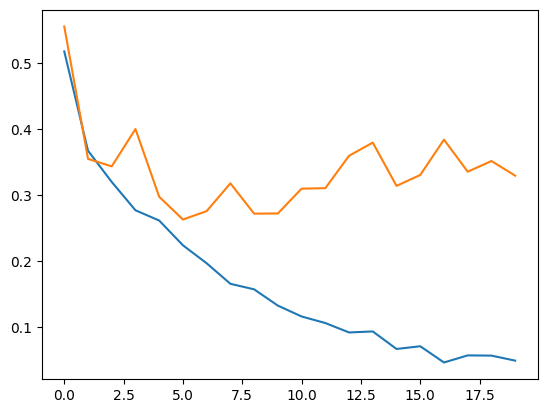

In [16]:
plt.plot(torch.stack(train_loss).detach().cpu())
plt.plot(torch.stack(test_loss).detach().cpu())

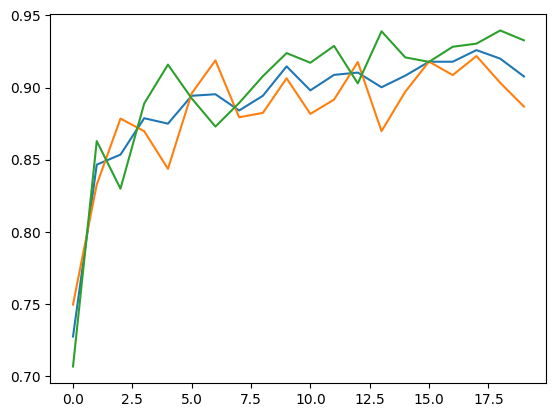

In [17]:
plt.plot([report['accuracy'] for report in test_metrics])
plt.plot([report['0']['precision'] for report in test_metrics])
plt.plot([report['1']['precision'] for report in test_metrics])

In [18]:
model.eval()

predicted_logits = []
actual = []

for img, label in tqdm(test_loader): 
    img = img.to('mps')    
    label = F.one_hot(label, 2).to(torch.float32).to('mps')

    with torch.no_grad():
        output = model(img)

    loss = criterion(output, label)

    y = label.argmax(dim=-1)

    predicted_logits.append(output)
    actual.append(y)

predicted_logits = torch.vstack(predicted_logits).cpu()
actual = torch.hstack(actual).cpu()

100%|██████████| 59/59 [00:17<00:00,  3.32it/s]


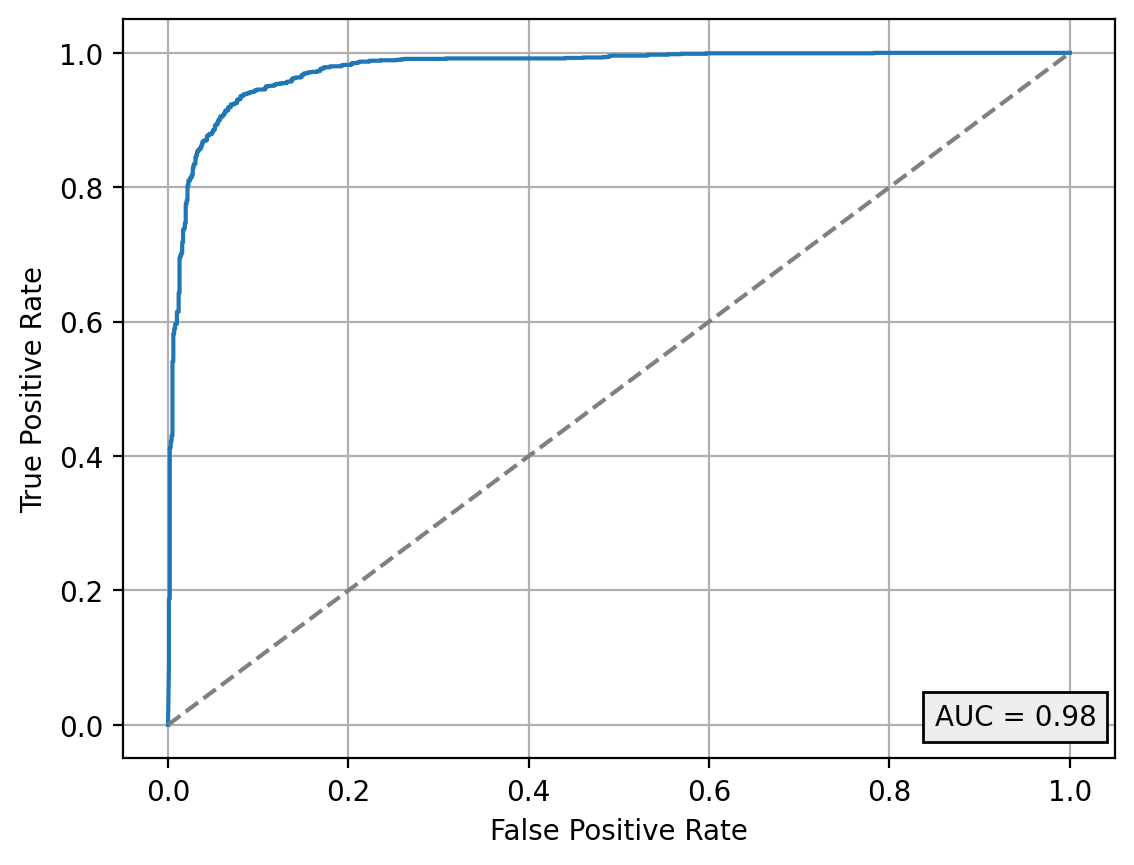

In [ ]:
from sklearn.metrics import auc, roc_curve

pos_logits = predicted_logits[:, 1]
probs = F.sigmoid(pos_logits)

fpr, tpr, _ = roc_curve(actual, probs)
roc_auc = auc(fpr, tpr)
plt.figure(dpi=200)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--', c='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.annotate(f"AUC = {roc_auc:.2f}", xy=(0.85, 0), bbox=dict(facecolor='#eee'))
plt.show()

In [ ]:
predicted = predicted_logits.argmax(dim=-1)
incorrect = torch.argwhere(predicted != actual)

In [ ]:
predicted

tensor([0, 0, 1,  ..., 1, 1, 1])

In [ ]:
incorrect_data = np.array(test_loader.dataset.dataset.samples)[incorrect]

In [ ]:
incorrect_df = df[np.isin(df['image'].tolist(), incorrect_data)]
incorrect_df.insert(len(incorrect_df.columns), 'benign', F.softmax(predicted_logits)[incorrect, 0])
incorrect_df.insert(len(incorrect_df.columns), 'mal', F.softmax(predicted_logits)[incorrect, 1])

/var/folders/jd/lb_vbvw54zd00wp54hlkx4_m0000gn/T/ipykernel_89886/3626754043.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  incorrect_df.insert(len(incorrect_df.columns), 'benign', F.softmax(predicted_logits)[incorrect, 0])
/var/folders/jd/lb_vbvw54zd00wp54hlkx4_m0000gn/T/ipykernel_89886/3626754043.py:3: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  incorrect_df.insert(len(incorrect_df.columns), 'mal', F.softmax(predicted_logits)[incorrect, 1])


In [ ]:
incorrect_df

,original,image,size,label,benign,mal
5795,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/0C2bAD25d59E7d82.png,10852238,1,0.000003,0.999997
5870,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/8a18A6e3A17EDEf5.png,178176,0,0.232083,0.767917
5897,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/3FDaFaa2adbC3EE9.png,14848,0,0.721262,0.278738
5916,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/AAb0eECfDBCfBDC8.png,64072,0,0.987728,0.012272
5933,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/3de57e9ddcdAAaB8.png,43952,0,0.725290,0.274710
...,...,...,...,...,...,...
11066,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/0ed822E9a11bB8D0.png,322560,0,0.233642,0.766358
11070,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/185Cd4C05E23BF30.png,151040,0,0.988746,0.011254
11074,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/3C82Bc6Ca193cc1d.png,1344000,0,0.127908,0.872092
11078,/Volumes/New Volume/malware-detection-dataset/...,./data/benign/Af3C8C76A1eAFfD3.png,1345024,0,0.894882,0.105118
